# 04 — Risk Quantification

Translates the Random Forest classifier's performance (notebook 03) into dollar-denominated risk measures: realized loss, a Monte Carlo simulation of future daily losses, and Value at Risk (VaR) / Conditional VaR (CVaR).

This is the step that turns a classification exercise into an actual risk-management artifact.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import joblib

df = pd.read_csv('../data/raw/creditcard.csv')
model = joblib.load('../data/processed/random_forest_model.pkl')

from sklearn.model_selection import train_test_split
X = df.drop('Class', axis=1)
y = df['Class']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

## 1. Realized loss on the test set

Of the actual frauds in the held-out test set, how much money did the model catch vs. miss?


In [2]:
y_pred = model.predict(X_test)

results = X_test.copy()
results['ActualClass'] = y_test.values
results['PredictedClass'] = y_pred

actual_frauds = results[results['ActualClass']==1]
missed = actual_frauds[actual_frauds['PredictedClass']==0]
caught = actual_frauds[actual_frauds['PredictedClass']==1]

print(f"Missed fraud: {len(missed)} transactions, ${missed['Amount'].sum():,.2f}")
print(f"Caught fraud: {len(caught)} transactions, ${caught['Amount'].sum():,.2f}")
print(f"\nRealized loss (missed):    ${missed['Amount'].sum():,.2f}")
print(f"Prevented loss (caught):   ${caught['Amount'].sum():,.2f}")
print(f"Loss reduction vs. no model: {caught['Amount'].sum()/(missed['Amount'].sum()+caught['Amount'].sum())*100:.1f}%")

Missed fraud: 25 transactions, $4,512.73
Caught fraud: 73 transactions, $6,132.20

Realized loss (missed):    $4,512.73
Prevented loss (caught):   $6,132.20
Loss reduction vs. no model: 57.6%


This single test-set figure is only one realization of many possible outcomes — actual daily fraud volume and amounts vary. To understand the *range* of plausible outcomes (and specifically the tail risk a bank needs to reserve capital against), we simulate many possible days.


## 2. Monte Carlo simulation of daily loss

For each of 10,000 simulated days:
1. Draw the number of fraudulent transactions from a Binomial distribution, using the dataset's overall fraud rate and daily transaction volume.
2. For each simulated fraud, draw a dollar amount by resampling from the empirical distribution of historical fraud amounts.
3. Apply the model's empirical miss rate (`1 - recall`) to randomly determine which of those frauds go undetected.
4. Sum the dollar amount of the *undetected* frauds — this is the day's realized loss.


In [3]:
np.random.seed(42)

fraud_amounts = df[df['Class']==1]['Amount'].values
total_days = df['Time'].max() / 86400
transactions_per_day = int(len(df) / total_days)
fraud_rate = df['Class'].mean()

# empirical recall of the Random Forest model, from notebook 03
recall = (results['ActualClass']==1) & (results['PredictedClass']==1)
model_recall = recall.sum() / (results['ActualClass']==1).sum()
model_miss_rate = 1 - model_recall

print(f"Transactions/day: {transactions_per_day}")
print(f"Fraud rate: {fraud_rate:.5f}")
print(f"Model recall: {model_recall:.3f}  |  miss rate: {model_miss_rate:.3f}")

Transactions/day: 142410
Fraud rate: 0.00173
Model recall: 0.745  |  miss rate: 0.255


In [4]:
n_simulations = 10000
daily_losses = np.zeros(n_simulations)

for i in range(n_simulations):
    n_frauds_today = np.random.binomial(transactions_per_day, fraud_rate)
    if n_frauds_today == 0:
        continue
    amounts_today = np.random.choice(fraud_amounts, size=n_frauds_today, replace=True)
    missed_today = np.random.random(n_frauds_today) < model_miss_rate
    daily_losses[i] = amounts_today[missed_today].sum()

print(f"Mean daily loss:  ${daily_losses.mean():,.2f}")
print(f"Min / Max:        ${daily_losses.min():,.2f} / ${daily_losses.max():,.2f}")

Mean daily loss:  $7,697.69
Min / Max:        $1,668.42 / $18,639.93


## 3. Value at Risk (VaR) and Conditional VaR (CVaR)

- **VaR (95%)**: the loss level that will not be exceeded on 95% of days (i.e. a 1-in-20-day tail event)
- **VaR (99%)**: the loss level that will not be exceeded on 99% of days (a 1-in-100-day tail event)
- **CVaR (95%)**: the *average* loss on the worst 5% of days — captures how bad the tail actually is beyond the VaR threshold, which VaR alone doesn't tell you


In [5]:
var_95 = np.percentile(daily_losses, 95)
var_99 = np.percentile(daily_losses, 99)
cvar_95 = daily_losses[daily_losses >= var_95].mean()

print(f"VaR (95%):  ${var_95:,.2f}")
print(f"VaR (99%):  ${var_99:,.2f}")
print(f"CVaR (95%): ${cvar_95:,.2f}")

VaR (95%):  $11,713.44
VaR (99%):  $13,784.58
CVaR (95%): $12,957.52


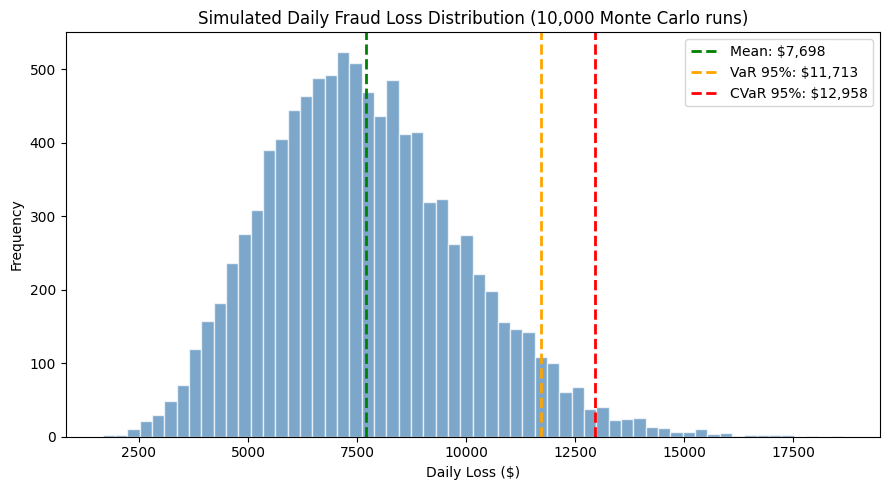

In [6]:
plt.figure(figsize=(9,5))
plt.hist(daily_losses, bins=60, color='steelblue', alpha=0.7, edgecolor='white')
plt.axvline(daily_losses.mean(), color='green', linestyle='--', linewidth=2, label=f'Mean: ${daily_losses.mean():,.0f}')
plt.axvline(var_95, color='orange', linestyle='--', linewidth=2, label=f'VaR 95%: ${var_95:,.0f}')
plt.axvline(cvar_95, color='red', linestyle='--', linewidth=2, label=f'CVaR 95%: ${cvar_95:,.0f}')
plt.xlabel('Daily Loss ($)')
plt.ylabel('Frequency')
plt.title('Simulated Daily Fraud Loss Distribution (10,000 Monte Carlo runs)')
plt.legend()
plt.tight_layout()
plt.show()

## Summary

- On the held-out test set, the model reduced realized fraud loss by roughly 58% compared to an unprotected baseline.
- Monte Carlo simulation translates the model's precision/recall into a full distribution of plausible future daily losses, rather than a single point estimate.
- VaR (95%) and CVaR (95%) give concrete capital-reserve reference points: a bank using this model could reasonably budget around the VaR/CVaR figures above to absorb tail-risk days, rather than only budgeting for the (misleadingly reassuring) average case.

### Limitations
- The simulation assumes the historical fraud-amount distribution and the model's recall stay constant going forward — in practice fraud patterns evolve, so this would need periodic re-calibration.
- The Random Forest model was evaluated on a single train/test split; a more rigorous treatment would use cross-validation to get a distribution of recall estimates (and propagate that uncertainty into the Monte Carlo simulation as well).
- No cost is assigned to false positives (customer friction, manual review cost) in this loss figure — a fuller treatment would net that against the prevented-loss figure.
